# imsocio Testing

This notebook provides manual testing procedures for verifying the functionality of imsocio. This can be used in combination with the streamlit app for testing.

**Purpose:** Demonstrate that each tool in imsocio produces expected outputs with sample data.

**Testing Approach:** Manual testing with documented steps and expected outcomes.

---

## Table of Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Test 1: Calibration](#2-test-1-calibration)
3. [Test 2: Generate Input Files](#3-test-2-generate-input-files)
4. [Test 3: Process Output Files](#4-test-3-process-output-files)
5. [Test 4: Get Calibrated Data](#5-test-4-get-calibrated-data)
6. [Test 5: Plot CCSDs](#6-test-5-plot-ccsds)
7. [Test 6: Fit Data](#7-test-6-fit-data)
8. [Test 7: Plot Mass Spectra](#8-test-7-plot-mass-spectra)
9. [Test 8: Generate Range Files](#9-test-8-generate-range-files)
10. [Test 9: ESIProt](#10-test-9-esiprot)
11. [Test 10: ORIGAMI CIU](#11-test-10-origami-ciu)
12. [Summary](#12-summary)

---

## 1. Setup and Imports

Import required libraries and verify imsocio is installed correctly.

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import imsocio modules
from imsocio import load_bush_database
from imsocio.calibration import CalibrantDatabase, CalibrantProcessor, InstrumentParams, adjust_dataframe_drift_times
from imsocio.io import write_imscal_dat, generate_zip_archive, generate_imscal_batch_file
from imsocio.extraction import InputProcessor, InputParams, OutputFileProcessor
from imsocio.processing import calculate_theoretical_mz, get_automatic_range, PROTON_MASS, fit_baseline_and_integrate
from imsocio.processing.drift_calibration import DriftCalibrationProcessor

print("✅ All imports successful!")
print(f"Working directory: {Path.cwd()}")

# ==================== INSTRUMENT CONFIGURATION ====================
# These settings are used across multiple tests

# Instrument type
instrument_type = "synapt"  # Options: "synapt" or "cyclic"

# Instrument parameters for calibration
velocity = 800  # m/s (wave velocity)
voltage = 15.0  # V (wave height)
pressure = 3    # mbar (IMS pressure)
length = 0.25   # m (drift cell length - 0.25 for Synapt, 0.98 for Cyclic)

# Calibrant database settings
calibrant_type = "nitrogen"  # Options: "nitrogen" or "helium"

# Quality control
min_r2 = 0.9  # R² threshold for calibration fits

# Cyclic-specific settings (only used if instrument_type == "cyclic")
inject_time = 0.0  # ms - set to ~10.0 for cyclic data

# ==================== SAMPLE CONFIGURATION ====================
# Sample masses and charge ranges for Test 4 (Get Calibrated Data)

# Sample masses (in Daltons)
sample_masses = {
    "mAb4": 147065.20  # From mab4_mass.csv
}

# Charge state ranges for each sample
# Format: {"sample_name": (min_charge, max_charge)}
sample_charge_ranges = {
    "mAb4": (21, 25)  # From ATD files: 21-25.txt
}

print(f"\n⚙️ INSTRUMENT CONFIGURATION")
print(f"   Type: {instrument_type}")
print(f"   Wave velocity: {velocity} m/s")
print(f"   Wave height: {voltage} V")
print(f"   Pressure: {pressure} mbar")
print(f"   Length: {length} m")
print(f"   Calibrant type: {calibrant_type}")
print(f"   Min R²: {min_r2}")
if instrument_type == "cyclic":
    print(f"   Inject time: {inject_time} ms")

print(f"\n🧪 SAMPLE CONFIGURATION")
for sample, mass in sample_masses.items():
    min_charge, max_charge = sample_charge_ranges[sample]
    print(f"   {sample}: {mass:.2f} Da (Z={min_charge}-{max_charge})")

✅ All imports successful!
Working directory: c:\Users\h87023ab\The University of Manchester Dropbox\Ana Clara Bath Alén\Barran_group_folder\Ana\writing\IMSpartacus\V2

⚙️ INSTRUMENT CONFIGURATION
   Type: synapt
   Wave velocity: 800 m/s
   Wave height: 15.0 V
   Pressure: 3 mbar
   Length: 0.25 m
   Calibrant type: nitrogen
   Min R²: 0.9

🧪 SAMPLE CONFIGURATION
   mAb4: 147065.20 Da (Z=21-25)


---

## 2. Test 1: Calibration

**Objective:** Verify that the calibration tool can process protein standard data and generate CCS calibration curves.

**Expected Outcome:** 
- Successfully load calibrant database
- Process calibrant data
- Generate calibration parameters
- Produce R² values > 0.9 for good calibrations

**Test Data Required:**
- Sample calibrant drift time data
- Bush protein database (included with imsocio)

In [2]:
# Test 1: Calibration
# This replicates the functionality of streamlit_app/pages/1_calibrate.py
# Uses instrument settings defined in Setup cell above

# Path to calibration data (already extracted)
calibration_data_path = Path("data/sample_data/calibration")

# Load Bush database
bush_df = load_bush_database()
print(f"✅ Bush database loaded: {len(bush_df)} entries")

# Initialize calibration components
db = CalibrantDatabase(bush_df)
processor = CalibrantProcessor(db, min_r2=min_r2)

# Get list of calibrant folders
calibrant_folders = [f for f in calibration_data_path.iterdir() if f.is_dir()]
print(f"\n📁 Found {len(calibrant_folders)} calibrant folders:")
for folder in calibrant_folders:
    print(f"  - {folder.name}")

# Process all calibrant folders
all_results = []
all_skipped = []
all_measurements_for_plots = []

print(f"\n🔬 Processing calibrant data with {calibrant_type} values...")
print(f"   Min R² threshold: {min_r2}")

for folder in calibrant_folders:
    folder_name = folder.name
    print(f"\n  Processing: {folder_name}")
    
    # Process folder using CalibrantProcessor
    measurements, skipped = processor.process_folder(
        folder,
        folder_name,
        calibrant_type
    )
    
    # Convert successful measurements to DataFrame
    if measurements:
        folder_df = pd.DataFrame([
            {
                'protein': m.protein,
                'mass': m.mass,
                'charge state': m.charge_state,
                'drift time': m.drift_time,
                'r2': m.r_squared,
                'calibrant_value': m.ccs_literature
            }
            for m in measurements
        ])
        all_results.append(folder_df)
        print(f"    ✅ {len(measurements)} charge states processed successfully")
    
    # Collect all measurements for plotting (successful + low R²)
    all_measurements_for_plots.extend(measurements)
    all_measurements_for_plots.extend([item for item in skipped if not isinstance(item, str)])
    
    # Format skipped entries
    for item in skipped:
        if isinstance(item, str):
            all_skipped.append(f"{folder_name} - {item}")
        else:
            all_skipped.append(
                f"{folder_name} charge {item.charge_state} - "
                f"R² ({item.r_squared:.3f}) below threshold ({min_r2:.1f})"
            )
            print(f"    ⚠️  Charge {item.charge_state}: R² = {item.r_squared:.3f} (below threshold)")

# Combine results into single DataFrame
results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

print(f"\n📊 RESULTS SUMMARY")
print(f"   Total charge states processed: {len(results_df)}")
print(f"   Skipped entries: {len(all_skipped)}")
print(f"\n✅ Test 1 Complete!")

# Display results
print("\n" + "="*70)
print("CALIBRATION RESULTS")
print("="*70)
print(results_df.to_string(index=False))

if all_skipped:
    print("\n" + "="*70)
    print("SKIPPED ENTRIES")
    print("="*70)
    for entry in all_skipped:
        print(f"  • {entry}")


✅ Bush database loaded: 43 entries

📁 Found 4 calibrant folders:
  - BSA
  - myoglobin
  - polyalanine10
  - polyalanine12

🔬 Processing calibrant data with nitrogen values...
   Min R² threshold: 0.9

  Processing: BSA
    ✅ 2 charge states processed successfully
    ⚠️  Charge 14: R² = 0.862 (below threshold)

  Processing: myoglobin
    ✅ 10 charge states processed successfully

  Processing: polyalanine10
    ⚠️  Charge 1: R² = 0.704 (below threshold)

  Processing: polyalanine12
    ⚠️  Charge 1: R² = 0.463 (below threshold)

📊 RESULTS SUMMARY
   Total charge states processed: 12
   Skipped entries: 4

✅ Test 1 Complete!

CALIBRATION RESULTS
  protein    mass  charge state  drift time       r2  calibrant_value
      BSA 66400.0            15   12.224611 0.987620             44.9
      BSA 66400.0            16   10.857933 0.987403             44.7
myoglobin 17000.0            15    9.925253 0.988576             40.6
myoglobin 17000.0            16    9.056717 0.991234             

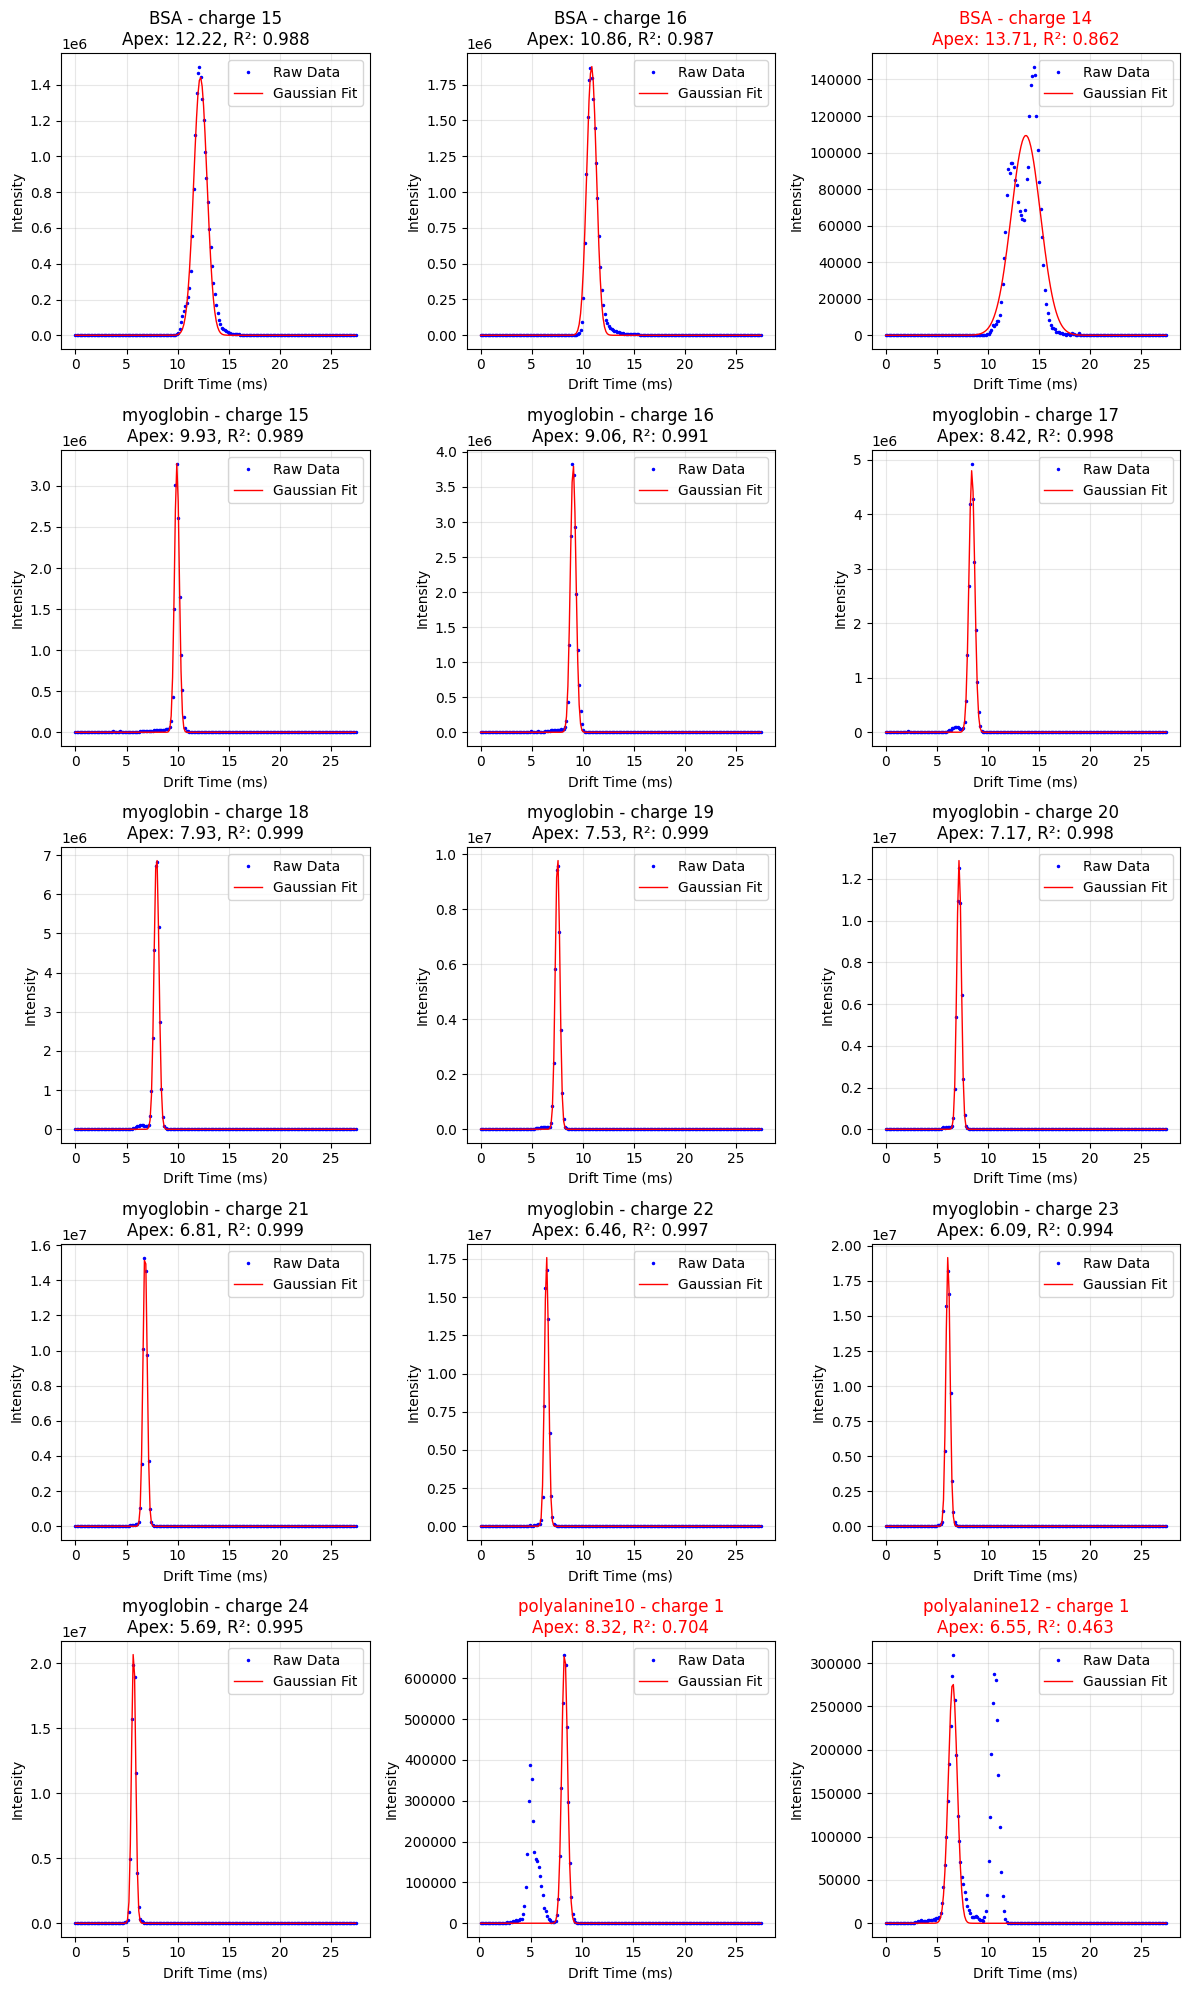


✅ Plotted 15 Gaussian fits
   Red titles indicate R² below threshold


In [3]:
# Plot Gaussian fits for all calibrants
# This replicates the plotting functionality from the streamlit app

# Filter to only measurements with fit results
measurements_with_fits = [m for m in all_measurements_for_plots if m.fit_result is not None]

if measurements_with_fits:
    n_plots = len(measurements_with_fits)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, measurement in enumerate(measurements_with_fits):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        fit = measurement.fit_result
        ax.plot(fit.drift_time, fit.intensity, 'b.', label='Raw Data', markersize=3)
        ax.plot(fit.drift_time, fit.fitted_values, 'r-', label='Gaussian Fit', linewidth=1)
        
        # Color code the title based on R² value
        title_color = 'red' if fit.r_squared < min_r2 else 'black'
        title = f'{measurement.protein} - charge {measurement.charge_state}\nApex: {fit.apex:.2f}, R²: {fit.r_squared:.3f}'
        ax.set_title(title, color=title_color)
        ax.set_xlabel('Drift Time (ms)')
        ax.set_ylabel('Intensity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(measurements_with_fits), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plotted {len(measurements_with_fits)} Gaussian fits")
    print("   Red titles indicate R² below threshold")
else:
    print("❌ No measurements with fit results to plot")


In [4]:
# Generate output files (CSV and .dat for IMSCal)
# This replicates the download functionality from the streamlit app
# Uses instrument settings defined in Setup cell above

if not results_df.empty:
    # Save CSV file
    csv_output_path = Path("data/sample_data/calibration/test_calibration_results.csv")
    results_df.to_csv(csv_output_path, index=False)
    print(f"✅ CSV results saved to: {csv_output_path}")
    
    # NOTE: For cyclic data, you would need to adjust drift times before generating the .dat file
    # Uncomment and modify the following section if using cyclic data:
    #
    # if instrument_type == "cyclic":
    #     instrument_params = InstrumentParams(
    #         wave_velocity=velocity,
    #         wave_height=voltage,
    #         pressure=pressure,
    #         drift_length=length,
    #         instrument_type=instrument_type,
    #         inject_time=inject_time
    #     )
    #     adjusted_df = adjust_dataframe_drift_times(results_df.copy(), instrument_params)
    #     print(f"✅ Drift times adjusted for cyclic data (inject time: {inject_time} ms)")
    # else:
    #     adjusted_df = results_df.copy()
    
    # For Synapt data, no drift time adjustment is needed
    adjusted_df = results_df.copy()
    
    # Generate .dat file for IMSCal
    dat_output_path = Path("data/sample_data/calibration/test_calibration.dat")
    write_imscal_dat(
        data=adjusted_df,
        output_path=dat_output_path,
        velocity=velocity,
        voltage=voltage,
        pressure=pressure,
        length=length
    )
    print(f"✅ .dat file for IMSCal saved to: {dat_output_path}")
    
    # Display statistics
    print(f"\n📈 CALIBRATION STATISTICS")
    print(f"   Number of proteins: {results_df['protein'].nunique()}")
    print(f"   Number of charge states: {len(results_df)}")
    print(f"   R² range: {results_df['r2'].min():.3f} - {results_df['r2'].max():.3f}")
    print(f"   Mean R²: {results_df['r2'].mean():.3f}")
    print(f"   Drift time range: {results_df['drift time'].min():.2f} - {results_df['drift time'].max():.2f} ms")
    
else:
    print("❌ No valid results to save")


✅ CSV results saved to: data\sample_data\calibration\test_calibration_results.csv
✅ .dat file for IMSCal saved to: data\sample_data\calibration\test_calibration.dat

📈 CALIBRATION STATISTICS
   Number of proteins: 2
   Number of charge states: 3
   R² range: 0.988 - 0.999
   Mean R²: 0.993
   Drift time range: 7.53 - 12.22 ms


## Test 2: Generate Input Files

This test replicates the functionality of `streamlit_app/pages/2_generate_input_files.py`.

**Purpose**: Generate IMSCal input files (.dat format) from Arrival Time Distribution (ATD) data extracted from Origami.

**What it does**:
- Reads ATD files (.txt or .csv) from sample folders
- Applies drift time corrections (if using Cyclic IMS)
- Combines with mass/charge information from CSV files
- Generates properly formatted `.dat` files for IMSCal input

**Note**: If the cell below fails with "Drift times must be positive", restart the kernel to reload the imsocio package (which has been fixed to allow zero drift times).

In [5]:
# Test 2: Generate Input Files
# This replicates the functionality of streamlit_app/pages/2_generate_input_files.py
# Uses instrument settings defined in Setup cell above

# Path to sample data (already extracted)
sample_data_path = Path("data/sample_data/IM1")

# Get list of sample folders
sample_folders = [f.name for f in sample_data_path.iterdir() if f.is_dir()]
print(f"📁 Found {len(sample_folders)} sample folders:")
for folder in sample_folders:
    print(f"  - {folder}")

# Define sample masses (in Daltons)
# You can get these from ESIProt or other deconvolution tools
sample_mass_map = {
    "mAb4": 147065.20  # From mab4_mass.csv
}

print(f"\n⚖️ Sample masses:")
for sample, mass in sample_mass_map.items():
    print(f"  {sample}: {mass:.2f} Da")

# Create processing parameters using instrument settings from Setup cell
# NOTE: For Cyclic data, set instrument_type="cyclic" and inject_time in Setup cell
params = InputParams(
    drift_mode=instrument_type.capitalize(),  # "Synapt" or "Cyclic"
    inject_time=inject_time,
    sample_mass_map=sample_mass_map
)

print(f"\n⚙️ Using instrument settings from Setup cell:")
print(f"  Drift mode: {instrument_type}")
if instrument_type == "cyclic":
    print(f"  Inject time: {inject_time} ms (will be subtracted from drift times)")

# Process all samples
print(f"\n🔬 Processing samples to generate IMSCal input files...")
processor = InputProcessor(base_path=sample_data_path, params=params)
result = processor.process_all(sample_folders)

# Display results
total_processed = sum(len(files) for files in result.processed_files.values())
total_failed = sum(len(files) for files in result.failed_files.values())

print(f"\n📊 PROCESSING RESULTS")
print(f"   Successfully processed: {total_processed} files")
print(f"   Failed to process: {total_failed} files")

print(f"\n✅ Detailed results:")
for sample in result.processed_files:
    print(f"  {sample}:")
    if result.processed_files[sample]:
        print(f"    ✅ Processed: {', '.join(result.processed_files[sample])}")
    if result.failed_files[sample]:
        print(f"    ❌ Failed:")
        for failed in result.failed_files[sample]:
            print(f"       - {failed}")

# Generate output files
if total_processed > 0:
    # Create ZIP archive
    zip_buffer = generate_zip_archive(result.sample_paths)
    
    # Save ZIP file
    output_zip_path = Path("data/sample_data/IM1/test_input_files.zip")
    with open(output_zip_path, 'wb') as f:
        f.write(zip_buffer.getvalue())
    print(f"\n✅ ZIP archive saved to: {output_zip_path}")
    
    # Also save individual .dat files for inspection
    print(f"\n📁 Generated .dat files:")
    for sample, sample_path in result.sample_paths.items():
        print(f"  {sample}:")
        for dat_file in Path(sample_path).glob("*.dat"):
            print(f"    - {dat_file.name}")
else:
    print("\n❌ No files were processed successfully")

print(f"\n✅ Test 2 Complete!")


📁 Found 1 sample folders:
  - mAb4

⚖️ Sample masses:
  mAb4: 147065.20 Da

⚙️ Using instrument settings from Setup cell:
  Drift mode: synapt

🔬 Processing samples to generate IMSCal input files...

📊 PROCESSING RESULTS
   Successfully processed: 5 files
   Failed to process: 0 files

✅ Detailed results:
  mAb4:
    ✅ Processed: 21.txt, 22.txt, 23.txt, 24.txt, 25.txt

✅ ZIP archive saved to: data\sample_data\IM1\test_input_files.zip

📁 Generated .dat files:
  mAb4:
    - input_21.dat
    - input_22.dat
    - input_23.dat
    - input_24.dat
    - input_25.dat
    - output_21.dat
    - output_22.dat
    - output_23.dat
    - output_24.dat
    - output_25.dat

✅ Test 2 Complete!


---

## 3. Generate IMSCal Batch File

**Objective:** Create a batch file to run IMSCal on the generated input files.

**Expected Outcome:**
- Generate a Windows batch script (.bat) that processes all input files through IMSCal
- Use instrument parameters from Setup cell
- Configure paths for input/output directories and calibration file

**Requirements:**
- IMSCal installed (default: `C:\Program Files\IMSCal19\bin`)
- Calibration .dat file from Test 1
- Input .dat files from Test 2


In [6]:
# Generate IMSCal Batch File
# Creates a .bat file to run IMSCal on all generated input files
# Uses instrument settings defined in Setup cell above

# Configuration
IMSCAL_BIN_PATH = r"C:\Program Files\IMSCal19\bin"  # Path to IMSCal installation
CALIBRATION_FILE = "data/sample_data/calibration/test_calibration.dat"  # From Test 1
INPUT_DIR = "data/sample_data/IM1/mAb4"  # Directory containing input_*.dat files
OUTPUT_DIR = "data/sample_data/IM1/mAb4"  # Where to save output_*.dat files
BATCH_FILE_PATH = "data/sample_data/IM1/run_imscal.bat"  # Output batch file

# IMSCal parameters (based on instrument configuration)
LAMBDA = 0.012  # Reduced mass parameter for nitrogen drift gas
TEMP = 300  # Temperature in Kelvin
ACCURACY = 2.0  # Accuracy parameter for IMSCal

print(f"📝 Generating IMSCal batch file...")

# Import the function (ensures latest version from library)
from imsocio.io.writers import generate_imscal_batch_file

# Generate the batch file using imsocio library function
batch_path = generate_imscal_batch_file(
    output_path=Path(BATCH_FILE_PATH),
    calibration_file=CALIBRATION_FILE,
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    velocity=velocity,
    voltage=voltage,
    pressure=pressure,
    length=length,
    imscal_bin_path=IMSCAL_BIN_PATH,
    lambda_value=LAMBDA,
    temperature=TEMP,
    accuracy=ACCURACY,
    instrument_type=instrument_type
)

print(f"✅ Batch file created: {batch_path}")
print(f"\n📋 To run IMSCal:")
print(f"   1. Ensure IMSCal is installed at: {IMSCAL_BIN_PATH}")
print(f"   2. Run the batch file: {batch_path}")
print(f"   3. This will process all input_*.dat files in {INPUT_DIR}")
print(f"   4. Output files will be saved to {OUTPUT_DIR}")

print(f"\n⚙️ Instrument parameters used:")
print(f"   Length: {length} m")
print(f"   Velocity: {velocity} m/s")
print(f"   Voltage: {voltage} V")
print(f"   Pressure: {pressure} mbar")
print(f"   Lambda: {LAMBDA}")
print(f"   Temperature: {TEMP} K")

print(f"\n✅ Batch file generation complete!")


📝 Generating IMSCal batch file...
✅ Batch file created: data\sample_data\IM1\run_imscal.bat

📋 To run IMSCal:
   1. Ensure IMSCal is installed at: C:\Program Files\IMSCal19\bin
   2. Run the batch file: data\sample_data\IM1\run_imscal.bat
   3. This will process all input_*.dat files in data/sample_data/IM1/mAb4
   4. Output files will be saved to data/sample_data/IM1/mAb4

⚙️ Instrument parameters used:
   Length: 0.25 m
   Velocity: 800 m/s
   Voltage: 15.0 V
   Pressure: 3 mbar
   Lambda: 0.012
   Temperature: 300 K

✅ Batch file generation complete!


---

## 4. Test 3: Process Output Files

**Objective:** Verify conversion of drift times to CCS values using calibration parameters.

**Expected Outcome:**
- Read IMSCal output files
- Apply calibration curve
- Convert drift times to CCS values
- Output calibrated data

**Test Data Required:**
- Sample IMSCal output file
- Calibration parameters from Test 1

In [7]:
# Test 3: Process Output Files
# This replicates the functionality of streamlit_app/pages/3_process_output_files.py
# Processes IMSCal output files to extract calibrated CCS data

from imsocio.extraction import OutputFileProcessor

# Path to directory containing output files
output_data_path = Path("data/sample_data/IM1")

print("🔬 Processing IMSCal output files...")
print(f"   Looking in: {output_data_path}\n")

# Process output files directly from directories
protein_outputs = {}
files_processed = 0

# Walk through sample folders looking for output_*.dat files
for sample_folder in output_data_path.iterdir():
    if not sample_folder.is_dir():
        continue
    
    protein_name = sample_folder.name
    output_files = list(sample_folder.glob("output_*.dat"))
    
    if not output_files:
        continue
    
    print(f"📁 Processing {protein_name}...")
    dataframes = []
    
    for output_file in sorted(output_files):
        try:
            # Parse the output file
            df = OutputFileProcessor.parse_output_file(output_file)
            dataframes.append(df)
            files_processed += 1
            print(f"   ✅ {output_file.name}: {len(df)} data points")
        except Exception as e:
            print(f"   ❌ {output_file.name}: {e}")
    
    if dataframes:
        # Store results for this protein
        from imsocio.extraction import ProteinOutput
        protein_outputs[protein_name] = ProteinOutput(
            protein_name=protein_name,
            dataframes=dataframes
        )
    print()

# Display results
print(f"📊 PROCESSING RESULTS")
print(f"   Files processed: {files_processed}")
print(f"   Proteins found: {len(protein_outputs)}")

if protein_outputs:
    print(f"\n✅ Calibrated data extracted successfully!\n")
    
    # For each protein, show details and save CSV
    for protein_name, protein_output in protein_outputs.items():
        # Combine all charge state data
        combined_df = OutputFileProcessor.combine_protein_data(protein_output)
        
        print(f"🧪 {protein_name}:")
        print(f"   Charge states: {len(protein_output.dataframes)}")
        print(f"   Total data points: {len(combined_df)}")
        print(f"   Charge range: {combined_df['Z'].min():.0f} - {combined_df['Z'].max():.0f}")
        print(f"   Drift time range: {combined_df['Drift'].min():.6f} - {combined_df['Drift'].max():.6f} ms")
        print(f"   CCS range: {combined_df['CCS'].min():.2f} - {combined_df['CCS'].max():.2f} Ų")
        
        # Save to CSV
        output_csv_path = Path(f"data/sample_data/IM1/{protein_name}/{protein_name}_calibration.csv")
        combined_df.to_csv(output_csv_path, index=False)
        print(f"   ✅ Saved to: {output_csv_path}")
        
        # Show sample of data
        print(f"\n   📋 Sample data (first 5 rows):")
        print(combined_df.head().to_string(index=False))
        print()
    
    print("="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Successfully processed {files_processed} output files")
    print(f"Extracted calibrated CCS data for {len(protein_outputs)} proteins")
    print("\nEach CSV file contains:")
    print("  • Z: Charge state")
    print("  • Drift: Drift time (ms)")
    print("  • CCS: Collision cross-section (Ų)")
    print("  • CCS Std.Dev.: Standard deviation")
    
else:
    print("❌ No valid output files found")

print(f"\n✅ Test 3 Complete!")


🔬 Processing IMSCal output files...
   Looking in: data\sample_data\IM1

📁 Processing mAb4...
   ✅ output_21.dat: 199 data points
   ✅ output_22.dat: 199 data points
   ✅ output_23.dat: 199 data points
   ✅ output_24.dat: 199 data points
   ✅ output_25.dat: 199 data points

📊 PROCESSING RESULTS
   Files processed: 5
   Proteins found: 1

✅ Calibrated data extracted successfully!

🧪 mAb4:
   Charge states: 5
   Total data points: 995
   Charge range: 21 - 25
   Drift time range: 0.000138 - 0.027512 ms
   CCS range: 2109.28 - 9305.62 Ų
   ✅ Saved to: data\sample_data\IM1\mAb4\mAb4_calibration.csv

   📋 Sample data (first 5 rows):
 Z    Drift     CCS  CCS Std.Dev.
21 0.000138 2109.28       54.5015
21 0.000276 2173.16       53.0095
21 0.000415 2235.81       51.6444
21 0.000553 2296.51       50.3766
21 0.000691 2355.76       49.1892

SUMMARY
Successfully processed 5 output files
Extracted calibrated CCS data for 1 proteins

Each CSV file contains:
  • Z: Charge state
  • Drift: Drift time (

---

## 5. Test 4: Get Calibrated Data

**Objective:** Verify integration of CCS data with mass spectra for quantitative analysis.

**Expected Outcome:**
- Combine calibrated CCS data with mass spectrum data
- Produce integrated dataset for further analysis

**Test Data Required:**
- Calibrated CCS data from Test 3
- Corresponding mass spectrum data

TEST 4A: GENERATE SCALE FACTORS FROM MASS SPECTRUM

══════════════════════════════════════════════════════════════════════
🔬 Processing mAb4
══════════════════════════════════════════════════════════════════════
   Mass: 147065.20 Da
   Charge range: 21 - 25

📊 Loading mass spectrum from: data\sample_data\IM1\mAb4\mass_spectrum.txt
✅ Loaded 357085 data points
   m/z range: 50.0 - 8000.0
   Intensity range: 0.0 - 276900.0

📐 Setting up integration ranges...

  Charge 21+:
    Theoretical m/z: 7004.11
    Integration range: 6829.01 - 7179.21 m/z

  Charge 22+:
    Theoretical m/z: 6685.79
    Integration range: 6518.64 - 6852.93 m/z

  Charge 23+:
    Theoretical m/z: 6395.15
    Integration range: 6235.27 - 6555.03 m/z

  Charge 24+:
    Theoretical m/z: 6128.72
    Integration range: 5975.51 - 6281.94 m/z

  Charge 25+:
    Theoretical m/z: 5883.62
    Integration range: 5736.52 - 6030.71 m/z

⚖️ Calculating scale factors for mAb4...
   Method: Baseline-corrected integration
   Smoothi

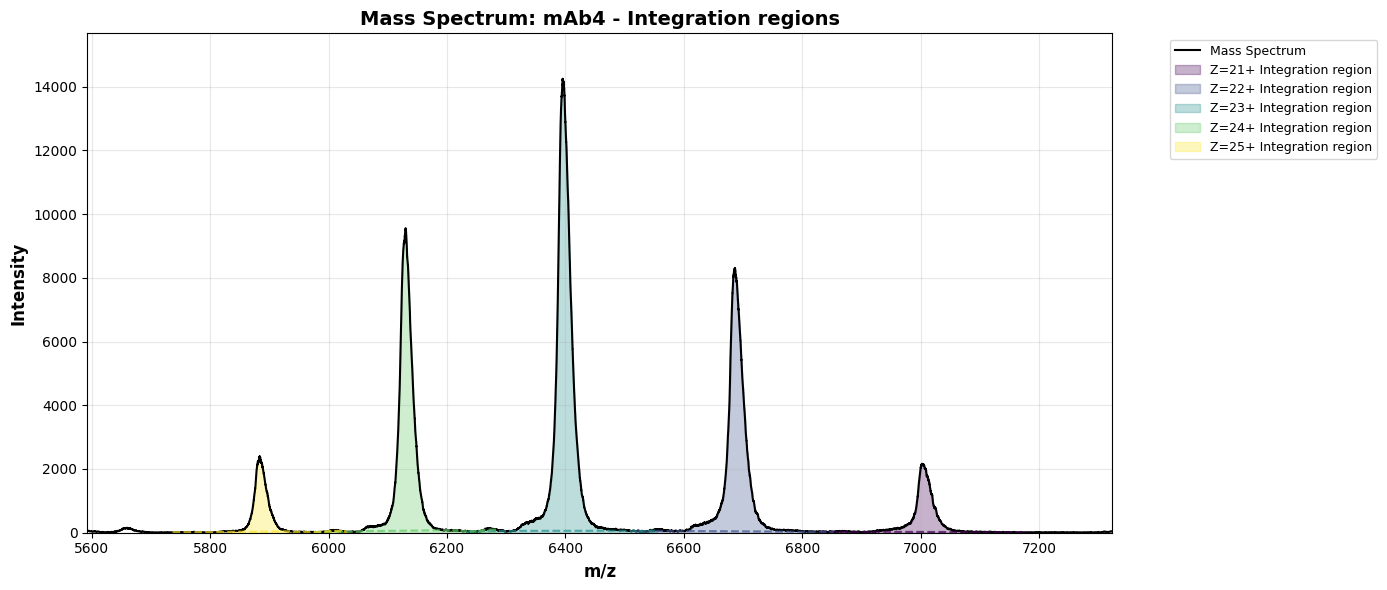


══════════════════════════════════════════════════════════════════════
SCALE FACTOR GENERATION COMPLETE!
══════════════════════════════════════════════════════════════════════
Total scale factors calculated: 5
Proteins processed: mAb4

💾 Saved scale factors to: data\sample_data\IM1\scale_factors.csv

📊 Scale Factors Summary:
Protein  Charge  Theoretical m/z   Range Min   Range Max  Scale Factor
   mAb4      21      7004.112038 6829.009237 7179.214839  69307.525274
   mAb4      22      6685.789094 6518.644367 6852.933822 251648.046047
   mAb4      23      6395.146406 6235.267746 6555.025067 397737.772475
   mAb4      24      6128.723943 5975.505844 6281.942041 248826.218160
   mAb4      25      5883.615276 5736.524894 6030.705658  59301.324460

✅ Test 4a Complete!
══════════════════════════════════════════════════════════════════════


In [8]:
# Test 4a: Generate Scale Factors from Mass Spectrum
# This is the first part of streamlit_app/pages/4_get_calibrated_data.py
# Calculates scale factors for normalizing charge state intensities

print("=" * 70)
print("TEST 4A: GENERATE SCALE FACTORS FROM MASS SPECTRUM")
print("=" * 70)

# Sample configuration (uses values from Setup cell)
sample_data_path = Path("data/sample_data/IM1")

# ==================== SCALE FACTOR METHOD ====================
# Choose how to calculate scale factors from the mass spectrum:
# - False: Use baseline-corrected integration (default, more accurate)
# - True: Use maximum intensity in range (faster, simpler)
use_max_intensity = False  # Change to True to use max intensity instead of integration

# Auto-range percentage (e.g., ±5% of theoretical m/z)
auto_range_percent = 2.5

# Smoothing window for mass spectrum
smoothing_window = 100

# Store all results
all_scale_factors = []
all_scale_ranges = {}

# Process each protein
for PROTEIN_NAME, PROTEIN_MASS in sample_masses.items():
    MIN_CHARGE, MAX_CHARGE = sample_charge_ranges[PROTEIN_NAME]
    
    print(f"\n{'═' * 70}")
    print(f"🔬 Processing {PROTEIN_NAME}")
    print(f"{'═' * 70}")
    print(f"   Mass: {PROTEIN_MASS:.2f} Da")
    print(f"   Charge range: {MIN_CHARGE} - {MAX_CHARGE}\n")

    # Load mass spectrum
    ms_path = sample_data_path / PROTEIN_NAME / "mass_spectrum.txt"
    print(f"📊 Loading mass spectrum from: {ms_path}")

    try:
        ms_df = pd.read_csv(ms_path, sep="\t", header=None, names=["m/z", "Intensity"])
        ms_df.dropna(inplace=True)
        print(f"✅ Loaded {len(ms_df)} data points")
        print(f"   m/z range: {ms_df['m/z'].min():.1f} - {ms_df['m/z'].max():.1f}")
        print(f"   Intensity range: {ms_df['Intensity'].min():.1f} - {ms_df['Intensity'].max():.1f}\n")
    except Exception as e:
        print(f"❌ Error loading mass spectrum for {PROTEIN_NAME}: {e}")
        continue

    # Set up m/z ranges for each charge state
    range_label = "search range" if use_max_intensity else "integration range"
    print(f"📐 Setting up {range_label}s...")

    protein_scale_factor_data = []

    for charge in range(MIN_CHARGE, MAX_CHARGE + 1):
        # Calculate theoretical m/z
        theoretical_mz = calculate_theoretical_mz(PROTEIN_MASS, charge)
        
        # Get automatic range
        range_min, range_max = get_automatic_range(theoretical_mz, auto_range_percent)
        
        # Store range
        all_scale_ranges[(PROTEIN_NAME, charge)] = (range_min, range_max)
        
        print(f"\n  Charge {charge}+:")
        print(f"    Theoretical m/z: {theoretical_mz:.2f}")
        print(f"    {range_label.capitalize()}: {range_min:.2f} - {range_max:.2f} m/z")

    # Calculate scale factors
    print(f"\n⚖️ Calculating scale factors for {PROTEIN_NAME}...")
    print(f"   Method: {'Maximum intensity' if use_max_intensity else 'Baseline-corrected integration'}")
    print(f"   Smoothing window: {smoothing_window}\n")

    for charge in range(MIN_CHARGE, MAX_CHARGE + 1):
        theoretical_mz = calculate_theoretical_mz(PROTEIN_MASS, charge)
        
        # Use core module function to calculate scale factor
        scale_factor, _ = DriftCalibrationProcessor.calculate_scale_factor(
            ms_df=ms_df,
            protein_name=PROTEIN_NAME,
            charge_state=charge,
            protein_mass=PROTEIN_MASS,
            scale_ranges=all_scale_ranges,
            use_max_intensity=use_max_intensity,
            smoothing_window=smoothing_window
        )
        
        if scale_factor is not None:
            range_min, range_max = all_scale_ranges[(PROTEIN_NAME, charge)]
            protein_scale_factor_data.append({
                "Protein": PROTEIN_NAME,
                "Charge": charge,
                "Theoretical m/z": theoretical_mz,
                "Range Min": range_min,
                "Range Max": range_max,
                "Scale Factor": scale_factor
            })
            print(f"  Charge {charge}+: Scale factor = {scale_factor:.2e}")
        else:
            print(f"  Charge {charge}+: ⚠️ Scale factor calculation failed")

    # Add to overall results
    all_scale_factors.extend(protein_scale_factor_data)
    
    # Plot mass spectrum with regions for this protein
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Smooth the mass spectrum for plotting
    from scipy.signal import savgol_filter
    smoothed_intensity = savgol_filter(ms_df['Intensity'], smoothing_window, 3)
    
    # Plot mass spectrum
    ax.plot(ms_df['m/z'], smoothed_intensity, 'k-', linewidth=1.5, label='Mass Spectrum')
    
    # Color map for charge states
    colors = plt.cm.viridis(np.linspace(0, 1, MAX_CHARGE - MIN_CHARGE + 1))
    
    # Highlight regions for each charge state
    region_label = "Search region" if use_max_intensity else "Integration region"
    
    for i, charge in enumerate(range(MIN_CHARGE, MAX_CHARGE + 1)):
        if (PROTEIN_NAME, charge) in all_scale_ranges:
            range_min, range_max = all_scale_ranges[(PROTEIN_NAME, charge)]
            
            # Create mask for this region
            mask = (ms_df['m/z'] >= range_min) & (ms_df['m/z'] <= range_max)
            
            # Fill region
            ax.fill_between(
                ms_df['m/z'][mask],
                0,
                smoothed_intensity[mask],
                alpha=0.3,
                color=colors[i],
                label=f'Z={charge}+ {region_label}'
            )
            
            # If using integration, also show baseline
            if not use_max_intensity:
                # Get baseline for this region
                region_mz = ms_df['m/z'][mask].values
                region_intensity = smoothed_intensity[mask]
                
                if len(region_mz) > 10:
                    _, baseline = fit_baseline_and_integrate(
                        region_mz, region_intensity, integration_range=(range_min, range_max)
                    )
                    ax.plot(region_mz, baseline, '--', color=colors[i], linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('m/z', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity', fontsize=12, fontweight='bold')
    ax.set_title(f'Mass Spectrum: {PROTEIN_NAME} - {region_label}s', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Zoom to region containing all charge states with some padding
    min_mz_all = min(all_scale_ranges[(PROTEIN_NAME, z)][0] for z in range(MIN_CHARGE, MAX_CHARGE + 1))
    max_mz_all = max(all_scale_ranges[(PROTEIN_NAME, z)][1] for z in range(MIN_CHARGE, MAX_CHARGE + 1))
    mz_padding = (max_mz_all - min_mz_all) * 0.1  # Add 10% padding on each side
    ax.set_xlim(min_mz_all - mz_padding, max_mz_all + mz_padding)
    
    # Scale y-axis to match the zoomed region
    zoom_mask = (ms_df['m/z'] >= min_mz_all - mz_padding) & (ms_df['m/z'] <= max_mz_all + mz_padding)
    if np.sum(zoom_mask) > 0:
        y_max = smoothed_intensity[zoom_mask].max()
        y_padding = y_max * 0.1  # Add 10% padding on top
        ax.set_ylim(0, y_max + y_padding)
    
    plt.tight_layout()
    plt.show()

# Create combined DataFrame with all proteins
scale_factors_df = pd.DataFrame(all_scale_factors)
scale_ranges = all_scale_ranges

print(f"\n{'═' * 70}")
print(f"SCALE FACTOR GENERATION COMPLETE!")
print(f"{'═' * 70}")
print(f"Total scale factors calculated: {len(scale_factors_df)}")
print(f"Proteins processed: {', '.join(sample_masses.keys())}")

# Save scale factors to CSV
scale_factors_path = sample_data_path / "scale_factors.csv"
scale_factors_df.to_csv(scale_factors_path, index=False)
print(f"\n💾 Saved scale factors to: {scale_factors_path}")

# Display the scale factors table
print(f"\n📊 Scale Factors Summary:")
print(scale_factors_df.to_string(index=False))

print(f"\n✅ Test 4a Complete!")
print(f"{'═' * 70}")

---

## 6. Test 4b: Generate Calibrated and Scaled Data

**Objective:** Generate calibrated and scaled CCSD data using scale factors.

**Workflow:**
1. Load ATD files for each protein and charge state
2. Normalize each ATD to maximum intensity = 1
3. Load calibration data from Test 3
4. Match calibration drift times to ATD data points
5. Apply scale factors from Test 4a
6. Output scaled intensity vs CCS for each protein/charge state

**Expected Output:**
- Calibrated and scaled data for each protein: `{protein}_scaled_calibrated.csv`
- Columns: Protein, Charge, Drift, CCS, CCS Std.Dev., Normalized_Intensity, Scaled_Intensity, m/z

In [9]:
print("=" * 70)
print("TEST 4B: GENERATE CALIBRATED AND SCALED DATA")
print("=" * 70)

# Sample configuration
sample_data_path = Path("data/sample_data/IM1")

# Store all calibrated/scaled data
all_proteins_data = []

# Process each protein
for PROTEIN_NAME, PROTEIN_MASS in sample_masses.items():
    MIN_CHARGE, MAX_CHARGE = sample_charge_ranges[PROTEIN_NAME]
    
    print(f"\n{'═' * 70}")
    print(f"🔬 Processing {PROTEIN_NAME}")
    print(f"{'═' * 70}")
    print(f"   Mass: {PROTEIN_MASS:.2f} Da")
    print(f"   Charge range: {MIN_CHARGE} - {MAX_CHARGE}\n")

    # Define paths
    atd_folder = sample_data_path / PROTEIN_NAME
    calibration_csv = sample_data_path / PROTEIN_NAME / f"{PROTEIN_NAME}_calibration.csv"
    
    print(f"📁 ATD folder: {atd_folder}")
    print(f"📄 Calibration CSV: {calibration_csv}")

    # Check if calibration file exists
    if not calibration_csv.exists():
        print(f"⚠️ Skipping {PROTEIN_NAME}: Calibration CSV not found")
        continue

    # Load calibration data
    try:
        calibration_df = pd.read_csv(calibration_csv)
        print(f"✅ Loaded calibration data with {len(calibration_df)} rows")
        print(f"   Columns: {', '.join(calibration_df.columns)}")
    except Exception as e:
        print(f"❌ Error loading calibration for {PROTEIN_NAME}: {e}")
        continue

    # Create a lookup for calibration data by charge state
    calibration_lookup = {}
    for _, row in calibration_df.iterrows():
        charge_state = int(row["Z"])
        if charge_state not in calibration_lookup:
            calibration_lookup[charge_state] = []
        calibration_lookup[charge_state].append({
            "Drift": row["Drift"],
            "CCS": row["CCS"],
            "CCS Std.Dev.": row["CCS Std.Dev."]
        })

    print(f"\n📊 Calibration data organized by charge state:")
    for charge in sorted(calibration_lookup.keys()):
        print(f"   Charge {charge}: {len(calibration_lookup[charge])} calibration points")

    # Process each charge state
    protein_scaled_data = []

    for charge in range(MIN_CHARGE, MAX_CHARGE + 1):
        print(f"\n{'─' * 70}")
        print(f"Processing {PROTEIN_NAME} charge state {charge}...")
        print(f"{'─' * 70}")
        
        # Check if we have calibration data for this charge
        if charge not in calibration_lookup:
            print(f"⚠ Skipping charge {charge}: No calibration data available")
            continue
        
        # Check if we have scale factor for this charge
        key = (PROTEIN_NAME, charge)
        if key not in scale_ranges:
            print(f"⚠ Skipping charge {charge}: No scale factor defined")
            continue
        
        # Load ATD file
        atd_file = atd_folder / f"{charge}.txt"
        if not atd_file.exists():
            print(f"⚠ Skipping charge {charge}: ATD file not found at {atd_file}")
            continue
        
        # Load and normalize ATD
        normalized_df = DriftCalibrationProcessor.load_and_normalize_atd(
            str(atd_file), instrument_type, inject_time
        )
        
        if normalized_df is None:
            print(f"⚠ Skipping charge {charge}: Could not load/normalize ATD")
            continue
        
        print(f"✅ Loaded ATD file: {atd_file.name}")
        print(f"   - {len(normalized_df)} data points")
        print(f"   - Drift time range: {normalized_df['Drift'].min():.2f} - {normalized_df['Drift'].max():.2f} ms")
        print(f"   - Normalized intensity range: {normalized_df['Intensity'].min():.4f} - {normalized_df['Intensity'].max():.4f}")
        
        # Get scale factor for this charge
        scale_factor_row = scale_factors_df[
            (scale_factors_df['Protein'] == PROTEIN_NAME) & 
            (scale_factors_df['Charge'] == charge)
        ]
        if scale_factor_row.empty:
            print(f"⚠ Skipping charge {charge}: Scale factor not found in DataFrame")
            continue
        
        scale_factor = scale_factor_row['Scale Factor'].values[0]
        theoretical_mz = scale_factor_row['Theoretical m/z'].values[0]
        
        print(f"   - Scale factor: {scale_factor:.2e}")
        print(f"   - Theoretical m/z: {theoretical_mz:.2f}")
        
        # Match calibration points to normalized ATD data
        cal_data = calibration_lookup[charge]
        matched_points = 0
        
        for entry in cal_data:
            drift_val = entry["Drift"]
            
            # Find closest drift time in normalized data
            closest_idx = (normalized_df["Drift"] - drift_val).abs().idxmin()
            normalized_intensity = normalized_df.loc[closest_idx, "Intensity"]
            
            # Apply scaling to normalized intensity
            scaled_intensity = normalized_intensity * scale_factor
            
            protein_scaled_data.append({
                "Protein": PROTEIN_NAME,
                "Charge": charge,
                "Drift": drift_val,
                "CCS": entry["CCS"],
                "CCS Std.Dev.": entry["CCS Std.Dev."],
                "Normalized_Intensity": normalized_intensity,
                "Scaled_Intensity": scaled_intensity,
                "m/z": theoretical_mz
            })
            matched_points += 1
        
        print(f"   ✅ Matched {matched_points} calibration points to ATD data")

    # Create DataFrame for this protein
    if protein_scaled_data:
        protein_df = pd.DataFrame(protein_scaled_data)
        all_proteins_data.extend(protein_scaled_data)
        
        # Save individual protein file
        scaled_output_path = sample_data_path / PROTEIN_NAME / f"{PROTEIN_NAME}_scaled_calibrated.csv"
        protein_df.to_csv(scaled_output_path, index=False)
        print(f"\n💾 Saved {PROTEIN_NAME} scaled calibrated data to: {scaled_output_path}")
        
        # Display summary statistics for this protein
        print(f"\n📊 Summary statistics for {PROTEIN_NAME}:")
        for charge in sorted(protein_df['Charge'].unique()):
            charge_data = protein_df[protein_df['Charge'] == charge]
            print(f"\n   Charge {charge}:")
            print(f"      - Data points: {len(charge_data)}")
            print(f"      - CCS range: {charge_data['CCS'].min():.1f} - {charge_data['CCS'].max():.1f} Ų")
            print(f"      - Scaled intensity range: {charge_data['Scaled_Intensity'].min():.2e} - {charge_data['Scaled_Intensity'].max():.2e}")

# Create combined DataFrame with all proteins
if all_proteins_data:
    scaled_df = pd.DataFrame(all_proteins_data)
    
    print(f"\n{'═' * 70}")
    print(f"PROCESSING COMPLETE!")
    print(f"{'═' * 70}")
    print(f"Total data points: {len(scaled_df)}")
    print(f"Proteins processed: {', '.join(scaled_df['Protein'].unique())}")
    
    # Save combined file
    combined_output_path = sample_data_path / "all_proteins_scaled_calibrated.csv"
    scaled_df.to_csv(combined_output_path, index=False)
    print(f"\n💾 Saved combined scaled calibrated data to: {combined_output_path}")
    
    # Display first few rows
    print(f"\n📋 Preview of scaled calibrated data:")
    print(scaled_df.head(15).to_string(index=False))
else:
    print(f"\n⚠️ No data processed!")

print(f"\n✅ Test 4b Complete!")
print(f"{'═' * 70}")

TEST 4B: GENERATE CALIBRATED AND SCALED DATA

══════════════════════════════════════════════════════════════════════
🔬 Processing mAb4
══════════════════════════════════════════════════════════════════════
   Mass: 147065.20 Da
   Charge range: 21 - 25

📁 ATD folder: data\sample_data\IM1\mAb4
📄 Calibration CSV: data\sample_data\IM1\mAb4\mAb4_calibration.csv
✅ Loaded calibration data with 995 rows
   Columns: Z, Drift, CCS, CCS Std.Dev.

📊 Calibration data organized by charge state:
   Charge 21: 199 calibration points
   Charge 22: 199 calibration points
   Charge 23: 199 calibration points
   Charge 24: 199 calibration points
   Charge 25: 199 calibration points

──────────────────────────────────────────────────────────────────────
Processing mAb4 charge state 21...
──────────────────────────────────────────────────────────────────────
✅ Loaded ATD file: 21.txt
   - 200 data points
   - Drift time range: 0.00 - 0.03 ms
   - Normalized intensity range: 0.0000 - 1.0000
   - Scale facto

TEST 5: PLOT COLLISION CROSS SECTION DISTRIBUTIONS

══════════════════════════════════════════════════════════════════════
📊 Plotting mAb4 CCSDs
══════════════════════════════════════════════════════════════════════
📁 Loading data from: data\sample_data\IM1\mAb4\mAb4_scaled_calibrated.csv
✅ Loaded 995 data points
   Charges present: [np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
   CCS range: 2109.3 - 9305.6 Ų

📏 Auto-detected CCS range: 1389.6 - 10025.3 Ų

📈 Generating summed CCSD plot...


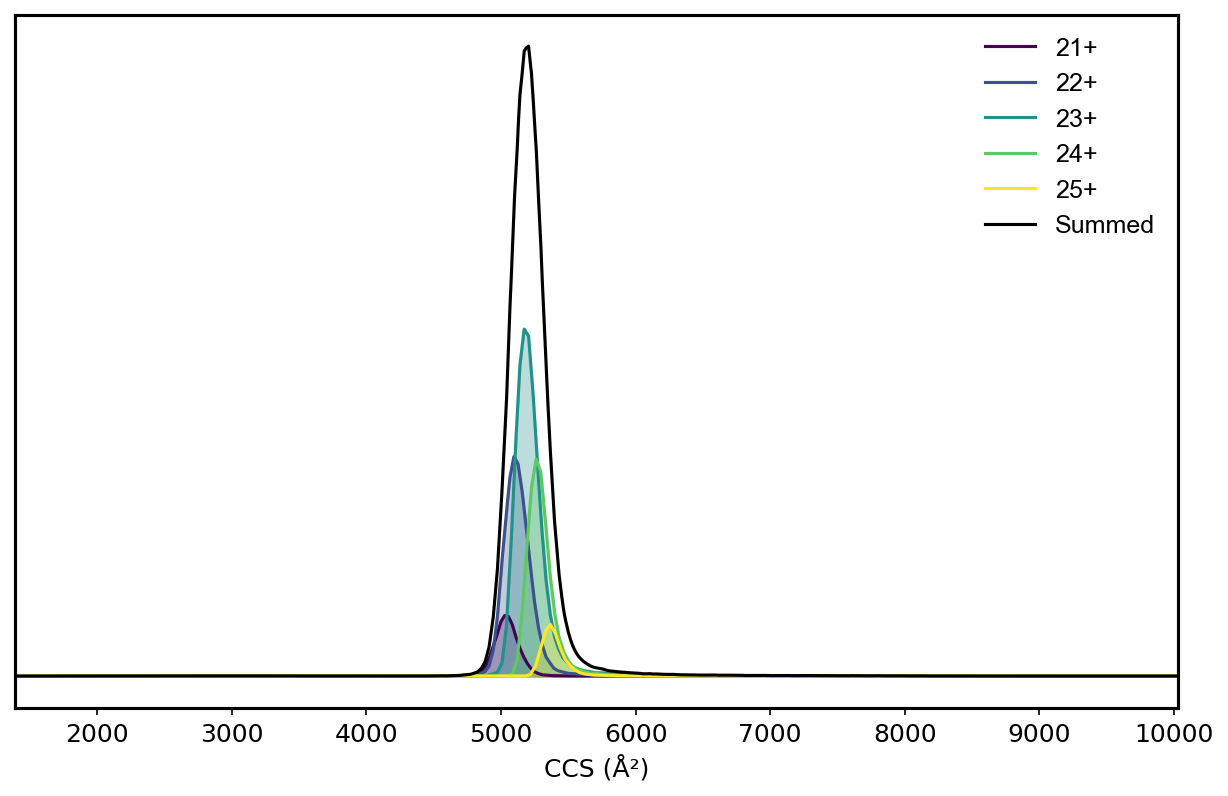


📈 Generating stacked CCSD plot...


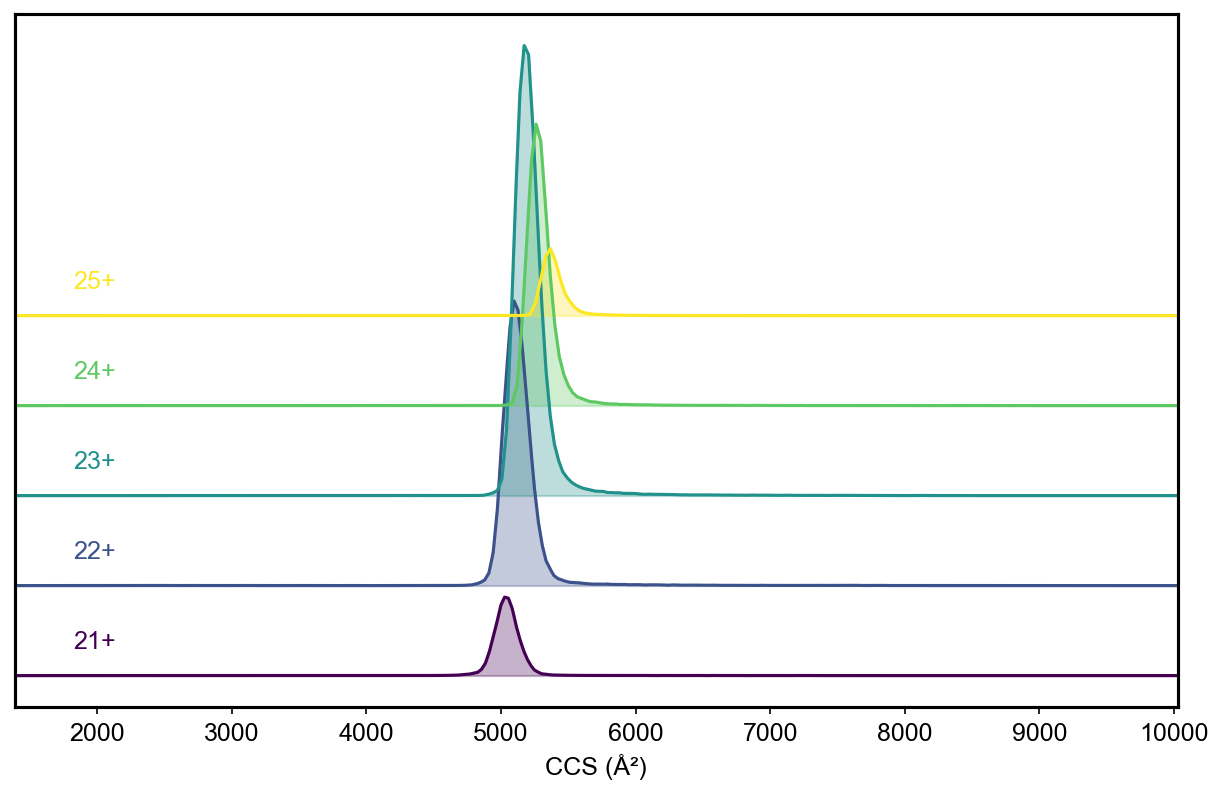


💾 Saved plots:
   - Summed: data\sample_data\IM1\mAb4\mAb4_ccsd_summed.png
   - Stacked: data\sample_data\IM1\mAb4\mAb4_ccsd_stacked.png

══════════════════════════════════════════════════════════════════════
CCSD PLOTTING COMPLETE!
══════════════════════════════════════════════════════════════════════

✅ Test 5 Complete!
══════════════════════════════════════════════════════════════════════


In [10]:
# Test 5: Plot CCSDs
# This replicates the functionality of streamlit_app/pages/5_plot_ccsds.py
# Plots calibrated and scaled CCS distributions

from imsocio.visualization import CCSDData, PlotSettings, CCSDPlotter

print("=" * 70)
print("TEST 5: PLOT COLLISION CROSS SECTION DISTRIBUTIONS")
print("=" * 70)

# Load the calibrated and scaled data from Test 4b
sample_data_path = Path("data/sample_data/IM1")

# Process each protein
for PROTEIN_NAME in sample_masses.keys():
    print(f"\n{'═' * 70}")
    print(f"📊 Plotting {PROTEIN_NAME} CCSDs")
    print(f"{'═' * 70}")
    
    # Load the scaled calibrated data
    scaled_csv_path = sample_data_path / PROTEIN_NAME / f"{PROTEIN_NAME}_scaled_calibrated.csv"
    
    if not scaled_csv_path.exists():
        print(f"⚠️ Skipping {PROTEIN_NAME}: Scaled calibrated CSV not found at {scaled_csv_path}")
        continue
    
    print(f"📁 Loading data from: {scaled_csv_path}")
    
    try:
        # Load data into CCSDData container
        df = pd.read_csv(scaled_csv_path)
        ccsd_data = CCSDData(df=df, filter_threshold=0.5)
        print(f"✅ Loaded {len(ccsd_data.df)} data points")
        print(f"   Charges present: {sorted(ccsd_data.df['Charge'].unique())}")
        print(f"   CCS range: {ccsd_data.df['CCS'].min():.1f} - {ccsd_data.df['CCS'].max():.1f} Ų")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        continue
    
    # Generate color palette for charge states
    n_charges = len(ccsd_data.df['Charge'].unique())
    trace_colors = plt.cm.viridis(np.linspace(0, 1, n_charges))
    
    # Get list of charge states to plot
    selected_charges = sorted(ccsd_data.df['Charge'].unique())
    
    # Auto-detect CCS range from data with some padding
    ccs_min_data = ccsd_data.df['CCS'].min()
    ccs_max_data = ccsd_data.df['CCS'].max()
    ccs_padding = (ccs_max_data - ccs_min_data) * 0.1  # 10% padding
    ccs_min = max(0, ccs_min_data - ccs_padding)  # Don't go below 0
    ccs_max = ccs_max_data + ccs_padding
    
    print(f"\n📏 Auto-detected CCS range: {ccs_min:.1f} - {ccs_max:.1f} Ų")
    
    # Generate summed plot (all charge states combined)
    print(f"\n📈 Generating summed CCSD plot...")
    
    # Configure plot settings for summed mode
    plot_settings_summed = PlotSettings(
        fig_width=10,
        fig_height=6,
        fig_dpi=150,
        font_size=12,
        font_family="Arial",
        line_thickness=1.5,
        plot_mode="Summed",  # Summed mode - all charge states combined
        use_scaled=True,  # Use scaled intensities
        ccs_min=ccs_min,  # Auto-detected minimum
        ccs_max=ccs_max,  # Auto-detected maximum
        trace_colors=trace_colors,
        bg_transparent=False,
        show_dashed_lines=True,
        show_ccs_labels=True,
        shade_under=True,
        black_lines=False,
        label_vertical_pos=0.95,
        label_orientation="Vertical"
    )
    
    fig_summed, maxima_info_summed, _ = CCSDPlotter.plot_ccs_traces(
        ccsd_data=ccsd_data,
        selected_charges=selected_charges,
        settings=plot_settings_summed
    )
    plt.show()
    
    # Generate stacked plot (charge states separated vertically)
    print(f"\n📈 Generating stacked CCSD plot...")
    
    # Configure plot settings for stacked mode
    plot_settings_stacked = PlotSettings(
        fig_width=10,
        fig_height=6,
        fig_dpi=150,
        font_size=12,
        font_family="Arial",
        line_thickness=1.5,
        plot_mode="Stacked",  # Stacked mode - charge states separated
        use_scaled=True,  # Use scaled intensities
        ccs_min=ccs_min,  # Auto-detected minimum
        ccs_max=ccs_max,  # Auto-detected maximum
        trace_colors=trace_colors,
        bg_transparent=False,
        show_dashed_lines=True,
        show_ccs_labels=True,
        shade_under=True,
        black_lines=False,
        label_vertical_pos=0.95,
        label_orientation="Vertical"
    )
    
    fig_stacked, maxima_info_stacked, _ = CCSDPlotter.plot_ccs_traces(
        ccsd_data=ccsd_data,
        selected_charges=selected_charges,
        settings=plot_settings_stacked
    )
    plt.show()
    
    # Save plots
    output_dir = sample_data_path / PROTEIN_NAME
    summed_path = output_dir / f"{PROTEIN_NAME}_ccsd_summed.png"
    stacked_path = output_dir / f"{PROTEIN_NAME}_ccsd_stacked.png"
    
    fig_summed.savefig(summed_path, dpi=plot_settings_summed.fig_dpi, bbox_inches='tight')
    fig_stacked.savefig(stacked_path, dpi=plot_settings_stacked.fig_dpi, bbox_inches='tight')
    
    print(f"\n💾 Saved plots:")
    print(f"   - Summed: {summed_path}")
    print(f"   - Stacked: {stacked_path}")
    
    plt.close(fig_summed)
    plt.close(fig_stacked)

print(f"\n{'═' * 70}")
print("CCSD PLOTTING COMPLETE!")
print(f"{'═' * 70}")
print(f"\n✅ Test 5 Complete!")
print(f"{'═' * 70}")

---

## 7. Test 6: Fit Data

**Objective:** Verify peak detection and fitting with multiple peak functions.

**Expected Outcome:**
- Detect peaks in CCS or mass spectrum data
- Fit peaks using Gaussian, pseudo-Voigt, or asymmetric Gaussian functions
- Report goodness-of-fit metrics (R², RMSE, reduced χ²)

**Test Data Required:**
- Sample data with distinguishable peaks (calibrated CCSD data from Test 4b)

**Workflow:**
1. Load calibrated and scaled CCSD data
2. Auto-detect peaks in the data
3. Fit Gaussian functions to detected peaks
4. Calculate goodness-of-fit metrics
5. Visualize fitted curves and components
6. Export fit parameters

CCSD PEAK FITTING WITH CONSTRAINED CENTROIDS

📁 Loading data from: data/sample_data/IM1/all_proteins_scaled_calibrated.csv
✅ Loaded 995 rows
   Available charges: [np.int8(21), np.int8(22), np.int8(23), np.int8(24), np.int8(25)]
   CCS range: 2109.28 - 9305.62 Ų

📊 Processing 5 charge states: [np.int8(21), np.int8(22), np.int8(23), np.int8(24), np.int8(25)]

📍 Centroid configuration:
   Charge 21: 1 peak(s) at [5000]
   Charge 22: 1 peak(s) at [5100]
   Charge 23: 1 peak(s) at [5200]
   Charge 24: 1 peak(s) at [5300]
   Charge 25: 1 peak(s) at [5400]


FITTING: Charge 21
Data points: 155
CCS range: 2109.28 - 6990.03 Ų
Centroids: [5000]
Constraint: ±2.0%

🔧 Applying baseline correction (None)...
📍 Setting up 1 peak(s)...
📊 Estimating initial parameters...
   Initial parameters: [np.float64(62106.72917091012), 5000.0, np.float64(41.4532737675575)]
🔒 Applying centroid constraints (±2.0%)...
   Peak 1: Centroid constrained to [4900.00, 5100.00]

⚙️ Setting up fitting engine...
🎯 Performing

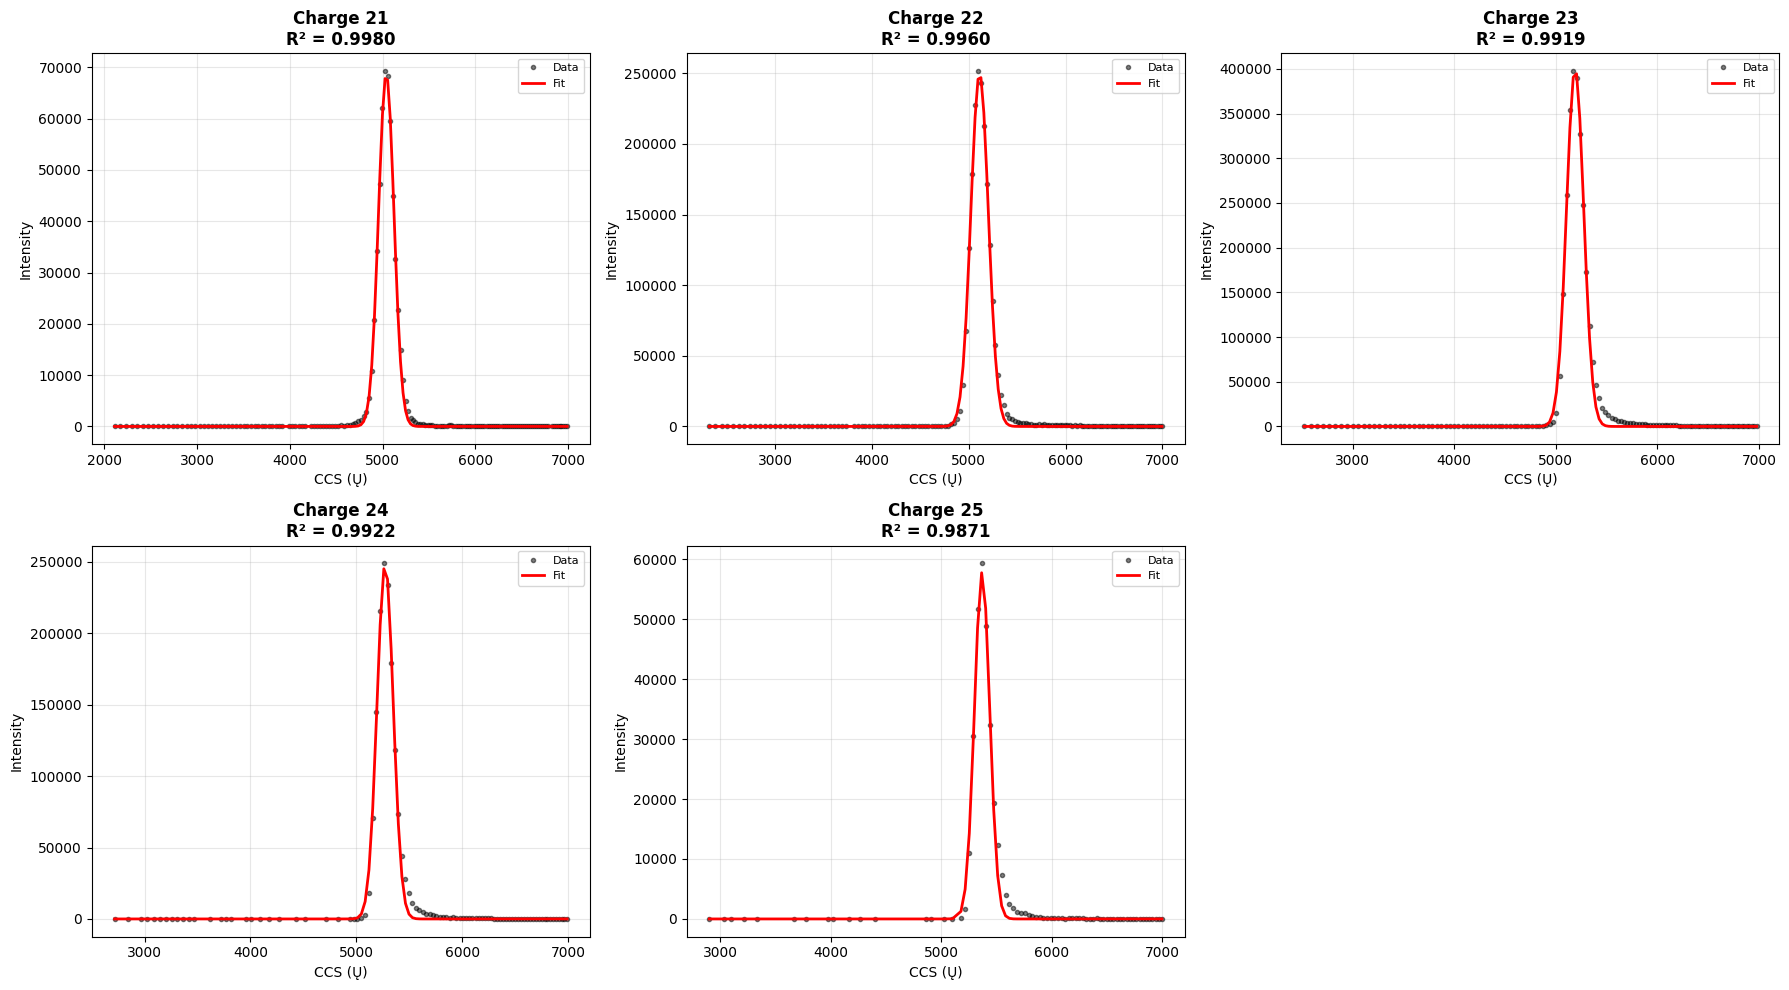

✅ Generated plots for 5 charge state(s)

✅ TEST 6 COMPLETE!


In [7]:
# ============================================================================
# TEST 6: FIT CCSD DATA - WITH CONSTRAINED CENTROIDS
# ============================================================================
# Simple Python script for fitting CCS distributions
# Option to fit either summed CCSD or all individual charge states

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import from imsocio package
from imsocio.fitting import (
    multi_peak_function,
    get_params_per_peak,
    get_parameter_names,
    ParameterEstimator,
    ParameterManager,
    FittingEngine,
    DataProcessor,
    ResultAnalyzer,
    CCSDDataProcessor
)

# ============================================================================
# PARAMETERS - EDIT THESE VALUES
# ============================================================================

# File path
CSV_FILE = r"data/sample_data/IM1/all_proteins_scaled_calibrated.csv"

# Analysis mode
MODE = "All Charge States"  # "All Charge States" or "Summed Data"

# CCS range to fit
CCS_MIN = 2000
CCS_MAX = 7000

# Centroid positions (REQUIRED)
# For "All Charge States" mode: Dictionary mapping charge state to list of centroids
# For "Summed Data" mode: Use key "Summed" with list of centroids
CENTROIDS = {
    21: [5000],
    22: [5100],
    23: [5200],
    24: [5300],
    25: [5400]
}
# Example for summed data:
# CENTROIDS = {"Summed": [4500, 5200, 6000]}

# Centroid constraint - allowed variation as percentage
CENTROID_TOLERANCE_PERCENT = 2.0  # ±2% of centroid value

# Fitting options
PEAK_TYPE = "Gaussian"  # "Gaussian", "Lorentzian", "Voigt", "BiGaussian", "EMG"
BASELINE_TYPE = "None"  # "None", "Linear", "Polynomial", "Exponential"
POLY_DEGREE = 2  # Only used if BASELINE_TYPE is "Polynomial"
FIT_METHOD = "Levenberg-Marquardt"  # "Levenberg-Marquardt" or "Global"
MAX_ITERATIONS = 1000
TOLERANCE = 1e-8

# Visualization
SHOW_COMPONENTS = True  # Show individual peak components in plots

# Export options
EXPORT_PARAMS = True  # Export fitted parameters to CSV
EXPORT_PATH = "data/sample_data/IM1/fit_parameters_all_charges.csv"

# ============================================================================
# WORKFLOW - NO NEED TO EDIT BELOW THIS LINE
# ============================================================================

print("="*70)
print("CCSD PEAK FITTING WITH CONSTRAINED CENTROIDS")
print("="*70)
print()

# Load data
print(f"📁 Loading data from: {CSV_FILE}")
df = pd.read_csv(CSV_FILE)

# Clean data
if 'CCS' in df.columns:
    df['CCS'] = pd.to_numeric(df['CCS'].astype(str).str.replace(',', ''), errors='coerce')
if 'Scaled_Intensity' in df.columns:
    df['Scaled_Intensity'] = pd.to_numeric(df['Scaled_Intensity'], errors='coerce')
if 'Charge' in df.columns:
    df['Charge'] = pd.to_numeric(df['Charge'], errors='coerce', downcast='integer')

df = df.dropna(subset=['Charge', 'CCS', 'Scaled_Intensity'])

print(f"✅ Loaded {len(df)} rows")
print(f"   Available charges: {sorted(df['Charge'].unique())}")
print(f"   CCS range: {df['CCS'].min():.2f} - {df['CCS'].max():.2f} Ų")
print()

# Apply CCS range filter
df_filtered = df[(df['CCS'] >= CCS_MIN) & (df['CCS'] <= CCS_MAX)].copy()

# Determine which charge states to process
if MODE == "All Charge States":
    charge_states = sorted(df_filtered['Charge'].unique())
    print(f"📊 Processing {len(charge_states)} charge states: {charge_states}")
    
    # Display centroid configuration
    print(f"\n📍 Centroid configuration:")
    for charge in charge_states:
        if charge in CENTROIDS:
            centroids = CENTROIDS[charge]
            print(f"   Charge {charge}: {len(centroids)} peak(s) at {centroids}")
        else:
            print(f"   Charge {charge}: ⚠️ No centroids defined - will be skipped")
    print()
elif MODE == "Summed Data":
    charge_states = ["Summed"]
    if "Summed" in CENTROIDS:
        print(f"📍 Summed data: {len(CENTROIDS['Summed'])} peak(s) at {CENTROIDS['Summed']}\n")
    else:
        print("⚠️ No centroids defined for summed data\n")
else:
    print(f"❌ Invalid MODE: {MODE}")
    charge_states = []

# Store all results
all_fit_results = []
all_fit_stats = []

# Process each charge state
for charge_state in charge_states:
    print("\n" + "="*70)
    
    # Get centroids for this charge state
    if charge_state == "Summed":
        if "Summed" not in CENTROIDS:
            print(f"⚠️ Summed Data: No centroids defined - skipping")
            continue
        current_centroids = CENTROIDS["Summed"]
        data_label = "Summed Data"
    else:
        if charge_state not in CENTROIDS:
            print(f"⚠️ Charge {charge_state}: No centroids defined - skipping")
            continue
        current_centroids = CENTROIDS[charge_state]
        data_label = f"Charge {charge_state}"
    
    print(f"FITTING: {data_label}")
    print("="*70)
    
    # Prepare data based on charge state
    if charge_state == "Summed":
        plot_data = CCSDDataProcessor.create_summed_data(df_filtered)
    else:
        plot_data = df_filtered[df_filtered['Charge'] == charge_state].copy()
        plot_data = plot_data.sort_values('CCS')
    
    # Filter positive intensities
    plot_data = plot_data[plot_data['Scaled_Intensity'] > 0]
    
    if len(plot_data) == 0:
        print(f"⚠️ No data available in specified range")
        continue
    
    x_data = plot_data['CCS'].values
    y_data = plot_data['Scaled_Intensity'].values
    
    print(f"Data points: {len(x_data)}")
    print(f"CCS range: {x_data.min():.2f} - {x_data.max():.2f} Ų")
    print(f"Centroids: {current_centroids}")
    print(f"Constraint: ±{CENTROID_TOLERANCE_PERCENT}%")
    print()
    
    # Initialize processor
    processor = DataProcessor()
    
    # Baseline subtraction
    print(f"🔧 Applying baseline correction ({BASELINE_TYPE})...")
    y_corrected, baseline = processor.subtract_baseline(
        x_data, y_data,
        method=BASELINE_TYPE,
        poly_degree=POLY_DEGREE
    )
    
    # Create peak info from centroids
    print(f"📍 Setting up {len(current_centroids)} peak(s)...")
    peak_info = []
    for centroid in current_centroids:
        # Find closest data point to centroid
        idx = np.argmin(np.abs(x_data - centroid))
        actual_x = x_data[idx]
        actual_y = y_corrected[idx]
        
        # Estimate width
        width_estimate = (x_data.max() - x_data.min()) * 0.02  # 2% of range
        
        peak_info.append({
            'index': idx,
            'x': centroid,
            'y': actual_y,
            'width_half': width_estimate,
            'area_estimate': actual_y * width_estimate
        })
    
    # Parameter estimation
    print("📊 Estimating initial parameters...")
    estimator = ParameterEstimator()
    initial_params = estimator.estimate_parameters(
        x_data, y_corrected, peak_info, PEAK_TYPE
    )
    print(f"   Initial parameters: {initial_params}")
    
    # Create parameter manager with centroid constraints
    print(f"🔒 Applying centroid constraints (±{CENTROID_TOLERANCE_PERCENT}%)...")
    x_range = (x_data.min(), x_data.max())
    param_manager = ParameterManager(PEAK_TYPE, initial_params, x_range)
    
    # Apply constraints to centroid parameters
    params_per_peak = get_params_per_peak(PEAK_TYPE)
    param_names = get_parameter_names(PEAK_TYPE)
    
    # Find the centroid parameter index (usually index 1)
    centroid_param_idx = None
    for i, name in enumerate(param_names):
        if name.lower() in ['center', 'mu', 'position', 'mean']:
            centroid_param_idx = i
            break
    
    if centroid_param_idx is not None:
        # Constrain each peak's centroid
        for peak_idx, centroid in enumerate(current_centroids):
            tolerance_abs = centroid * (CENTROID_TOLERANCE_PERCENT / 100.0)
            lower_bound = centroid - tolerance_abs
            upper_bound = centroid + tolerance_abs
            
            param_manager.set_parameter_bounds(
                peak_idx, 
                centroid_param_idx, 
                lower_bound, 
                upper_bound
            )
            print(f"   Peak {peak_idx+1}: Centroid constrained to [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print("   ⚠️ Could not identify centroid parameter - no constraints applied")
    
    # Setup fitting engine
    print("\n⚙️ Setting up fitting engine...")
    engine = FittingEngine()
    engine.set_fitting_options(
        peak_type=PEAK_TYPE,
        baseline_type="None",  # Already subtracted
        fit_method=FIT_METHOD,
        max_iterations=MAX_ITERATIONS,
        tolerance=TOLERANCE,
        use_weights=False
    )
    engine.set_parameter_manager(param_manager)
    
    # Perform fitting
    print("🎯 Performing fit...")
    try:
        # Use fit_peaks method (not fit)
        result = engine.fit_peaks(x_data, y_corrected, initial_params, weights=None)
        
        if result['success']:
            print("✅ Fit successful!")
            print(f"   R² = {result['r_squared']:.4f}")
            print(f"   Adjusted R² = {result['adj_r_squared']:.4f}")
            print(f"   RMSE = {result['rmse']:.4f}")
            print(f"   Reduced χ² = {result['reduced_chi_squared']:.4f}")
            
            # Extract peak statistics - use correct signature
            analyzer = ResultAnalyzer()
            peak_stats = analyzer.calculate_peak_statistics(
                x_data,
                y_corrected,
                result['fitted_curve'],
                result['parameters'],
                PEAK_TYPE
            )
            
            # Store results
            if peak_stats is not None:
                for stat in peak_stats:
                    stat['Charge'] = charge_state
                    all_fit_stats.append(stat)
            else:
                print("   ⚠️ Could not calculate peak statistics")
            
            all_fit_results.append({
                'charge': charge_state,
                'x_data': x_data,
                'y_data': y_data,
                'y_corrected': y_corrected,
                'baseline': baseline,
                'result': result
            })
            
        else:
            print(f"⚠️ Fit failed: {result.get('message', result.get('error', 'Unknown error'))}")
            
    except Exception as e:
        print(f"❌ Fitting error: {str(e)}")

# ============================================================================
# VISUALIZATION
# ============================================================================

if all_fit_results:
    print("\n" + "="*70)
    print("VISUALIZATION")
    print("="*70)
    
    n_results = len(all_fit_results)
    n_cols = min(3, n_results)
    n_rows = (n_results + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    
    # Handle single plot case
    if n_results == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, fit_data in enumerate(all_fit_results):
        ax = axes[idx]
        charge = fit_data['charge']
        x_data = fit_data['x_data']
        y_data = fit_data['y_data']
        y_corrected = fit_data['y_corrected']
        baseline = fit_data['baseline']
        result = fit_data['result']
        
        # Plot original data
        ax.plot(x_data, y_data, 'o', color='black', markersize=3, 
                alpha=0.5, label='Data')
        
        # Plot baseline if present
        if not np.allclose(baseline, 0):
            ax.plot(x_data, baseline, '--', color='gray', 
                   linewidth=1, label='Baseline')
        
        # Plot fitted curve (add baseline back)
        fitted_curve = result['fitted_curve'] + baseline
        ax.plot(x_data, fitted_curve, '-', color='red', 
               linewidth=2, label='Fit')
        
        # Plot individual components if requested
        if SHOW_COMPONENTS and 'peak_components' in result:
            colors = plt.cm.Set2(np.linspace(0, 1, len(result['peak_components'])))
            for i, component in enumerate(result['peak_components']):
                component_with_baseline = component + baseline
                ax.plot(x_data, component_with_baseline, '--', 
                       color=colors[i], linewidth=1.5, alpha=0.7,
                       label=f'Peak {i+1}')
        
        # Labels and title
        if charge == "Summed":
            title = f"Summed CCSD\nR² = {result['r_squared']:.4f}"
        else:
            title = f"Charge {charge}\nR² = {result['r_squared']:.4f}"
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('CCS (Ų)', fontsize=10)
        ax.set_ylabel('Intensity', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_results, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Generated plots for {n_results} charge state(s)")

# ============================================================================
# EXPORT RESULTS
# ============================================================================

if EXPORT_PARAMS and all_fit_stats:
    print("\n" + "="*70)
    print("EXPORT")
    print("="*70)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(all_fit_stats)
    
    # Save to CSV
    export_path = Path(EXPORT_PATH)
    export_path.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(export_path, index=False)
    
    print(f"💾 Fit parameters exported to: {export_path}")
    print(f"   {len(results_df)} peak parameter sets saved")
    
    # Display preview
    print(f"\n📊 Fit Parameters Preview:")
    print(results_df.to_string(index=False))

print("\n" + "="*70)
print("✅ TEST 6 COMPLETE!")
print("="*70)


---

## 11. Test 10: ORIGAMI CIU

**Objective:** Verify generation of collision-induced unfolding (CIU) fingerprint heatmaps.

**Expected Outcome:**
- Process CIU data (collision voltage vs drift time/CCS)
- Generate ORIGAMI-style heatmap visualization
- Support interpolation and smoothing options

**Test Data Required:**
- CIU data with varying collision voltages

In [ ]:
# Test 10: ORIGAMI CIU
# Create ORIGAMI-style collision-induced unfolding (CIU) heatmap
# Replicates functionality from streamlit_app/pages/10_origami_ciu.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import from imsocio package
from imsocio.processing import (
    ORIGAMISettings,
    ORIGAMIDataProcessor,
    ORIGAMIVisualizer
)

print("="*70)
print("TEST 10: ORIGAMI CIU - COLLISION-INDUCED UNFOLDING HEATMAP")
print("="*70)
print()

# ============================================================================
# GENERATE SYNTHETIC CIU DATA FOR TESTING
# ============================================================================
# Since we don't have real CIU data, let's create synthetic data
# that simulates a protein unfolding as collision voltage increases

print("📊 Generating synthetic CIU data...")
print("   (Simulating protein unfolding with increasing collision voltage)\n")

# Parameters for synthetic data
num_cv_points = 20  # Number of collision voltage steps
num_dt_points = 100  # Number of drift time bins
cv_min, cv_max = 10.0, 200.0  # Collision voltage range (V)
dt_min, dt_max = 2.0, 12.0  # Drift time range (ms)

# Create arrays for data points
data_points = []

# Simulate protein unfolding:
# - At low CV: compact state (narrow peak at low drift time)
# - At high CV: extended state (broader peak at high drift time)
# - Middle CV: transition between states

for cv in np.linspace(cv_min, cv_max, num_cv_points):
    for dt in np.linspace(dt_min, dt_max, num_dt_points):
        # Calculate transition progress (0 = compact, 1 = extended)
        transition = 1 / (1 + np.exp(-(cv - 100) / 20))  # Sigmoid
        
        # Compact state peak (narrow, low DT)
        compact_center = dt_min + 0.25 * (dt_max - dt_min)
        compact_width = 0.05 * (dt_max - dt_min)
        compact_intensity = (1 - transition) * np.exp(-((dt - compact_center) ** 2) / (2 * compact_width ** 2))
        
        # Extended state peak (broader, high DT)
        extended_center = dt_min + 0.7 * (dt_max - dt_min)
        extended_width = 0.15 * (dt_max - dt_min)
        extended_intensity = transition * np.exp(-((dt - extended_center) ** 2) / (2 * extended_width ** 2))
        
        # Combine states and add noise
        intensity = compact_intensity + extended_intensity + np.random.normal(0, 0.02)
        intensity = max(0, intensity)  # No negative intensities
        
        # Store data point
        data_points.append({
            'Drift_Time': dt,
            'CV': cv,
            'Intensity': intensity
        })

# Create DataFrame
df = pd.DataFrame(data_points)

print(f"✅ Generated synthetic data:")
print(f"   Collision voltages: {cv_min} - {cv_max} V ({num_cv_points} steps)")
print(f"   Drift times: {dt_min} - {dt_max} ms ({num_dt_points} bins)")
print(f"   Total data points: {len(df):,}")
print(f"   Intensity range: {df['Intensity'].min():.3f} - {df['Intensity'].max():.3f}")

# ============================================================================
# ORIGAMI PROCESSING SETTINGS
# ============================================================================
print(f"\n{'─'*70}")
print("⚙️ ORIGAMI PROCESSING SETTINGS")
print(f"{'─'*70}")

# Create settings with correct parameters
GRID_RESOLUTION = 200
INTERP_METHOD = "cubic"
NORMALIZE_DATA = True
NORM_MODE = "Maximum"
APPLY_SMOOTHING = True
SMOOTHING_TYPE = "gaussian"
GAUSSIAN_SIGMA = 2.0
COLORMAP = "viridis"
FIGURE_SIZE = 8.0
DPI = 150

print(f"Grid resolution: {GRID_RESOLUTION}")
print(f"Interpolation: {INTERP_METHOD}")
print(f"Normalize: {NORMALIZE_DATA} ({NORM_MODE})")
print(f"Smoothing: {SMOOTHING_TYPE if APPLY_SMOOTHING else 'None'}")
if APPLY_SMOOTHING:
    print(f"   σ={GAUSSIAN_SIGMA}")
print(f"Colormap: {COLORMAP}")

# ============================================================================
# CREATE ORIGAMI SETTINGS OBJECT
# ============================================================================
print(f"\n{'─'*70}")
print("🔧 Creating ORIGAMI settings...")
print(f"{'─'*70}")

settings = ORIGAMISettings(
    # Grid and interpolation
    grid_resolution=GRID_RESOLUTION,
    interpolation_method=INTERP_METHOD,
    
    # Normalization
    normalize_data=NORMALIZE_DATA,
    normalization_mode=NORM_MODE,
    
    # Smoothing
    apply_smoothing=APPLY_SMOOTHING,
    smoothing_type=SMOOTHING_TYPE,
    gaussian_sigma=GAUSSIAN_SIGMA,
    
    # Plot appearance
    colormap=COLORMAP,
    show_colorbar=True,
    
    # Figure
    figure_size=FIGURE_SIZE,
    dpi=DPI,
    font_size=12
)

print("✅ Settings configured")

# ============================================================================
# CREATE VISUALIZATION
# ============================================================================
print(f"\n{'─'*70}")
print("📊 Creating ORIGAMI-style heatmap...")
print(f"{'─'*70}")

# Create the figure using ORIGAMIVisualizer static method
fig, buffer = ORIGAMIVisualizer.create_plot(
    df=df,
    settings=settings,
    x_label='Drift Time (ms)',
    y_label='Collision Voltage (V)',
    title='Synthetic Protein CIU Fingerprint',
    cmap_label='Normalized Intensity',
    transparent_bg=False
)

# Display the plot
plt.show()

# Save the figure
output_path = Path("data/sample_data") / "origami_ciu_synthetic.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=DPI, bbox_inches='tight')
print(f"\n💾 Saved heatmap to: {output_path}")

# ============================================================================
# DISPLAY SUMMARY STATISTICS
# ============================================================================
print(f"\n{'─'*70}")
print("📈 SUMMARY STATISTICS")
print(f"{'─'*70}")

print(f"\nData Dimensions:")
print(f"   CV range: {df['CV'].min():.1f} - {df['CV'].max():.1f} V")
print(f"   DT range: {df['Drift_Time'].min():.2f} - {df['Drift_Time'].max():.2f} ms")
print(f"   Data points: {len(df):,}")
print(f"   Intensity range: {df['Intensity'].min():.3f} - {df['Intensity'].max():.3f}")

print(f"\nProcessing Applied:")
print(f"   ✓ Interpolation: {INTERP_METHOD} ({GRID_RESOLUTION}×{GRID_RESOLUTION} grid)")
print(f"   ✓ Normalization: {NORM_MODE}")
if APPLY_SMOOTHING:
    print(f"   ✓ Smoothing: {SMOOTHING_TYPE} (σ={GAUSSIAN_SIGMA})")

print(f"\n✅ Test 10 Complete!")
print("="*70)
print()
print("💡 NOTE: This test uses synthetic data simulating protein unfolding.")
print("   Real CIU data would come from TWIMExtract processing of IMS experiments")
print("   with varying collision voltages.")
print()
print("🔬 The heatmap shows the characteristic 'CIU fingerprint' with:")
print("   - Compact state (low DT) dominant at low collision voltages")
print("   - Extended state (high DT) dominant at high collision voltages")
print("   - Smooth transition region in the middle")


TEST 10: ORIGAMI CIU - COLLISION-INDUCED UNFOLDING HEATMAP

📊 Generating synthetic CIU data...
   (Simulating protein unfolding with increasing collision voltage)

✅ Generated synthetic data:
   Collision voltages: 10.0 - 200.0 V (20 steps)
   Drift times: 2.0 - 12.0 ms (100 bins)
   Matrix shape: (100, 20) (DT x CV)
   Intensity range: 0.000 - 1.025

──────────────────────────────────────────────────────────────────────
⚙️ ORIGAMI PROCESSING SETTINGS
──────────────────────────────────────────────────────────────────────
Grid resolution: 200
Interpolation: cubic
Normalize: True (Maximum)
Smoothing: gaussian
   σ=2.0
Colormap: viridis

──────────────────────────────────────────────────────────────────────
🔧 Creating ORIGAMI settings...
──────────────────────────────────────────────────────────────────────
✅ Settings configured

──────────────────────────────────────────────────────────────────────
📊 Creating ORIGAMI-style heatmap...
──────────────────────────────────────────────────────

TypeError: ORIGAMIVisualizer() takes no arguments

---

## 12. Summary

**Test Results Overview:**

This section will document the results of all tests above.

| Test | Tool | Status | Notes |
|------|------|--------|-------|
| 1 | Calibration | ⬜ Not Run | |
| 2 | Generate Input Files | ⬜ Not Run | |
| 3 | Process Output Files | ⬜ Not Run | |
| 4 | Get Calibrated Data | ⬜ Not Run | |
| 5 | Plot CCSDs | ⬜ Not Run | |
| 6 | Fit Data | ⬜ Not Run | |
| 7 | Plot Mass Spectra | ⬜ Not Run | |
| 8 | Generate Range Files | ⬜ Not Run | |
| 9 | ESIProt | ⬜ Not Run | |
| 10 | ORIGAMI CIU | ⬜ Not Run | |

**Conclusion:**

Update this section after completing all tests to confirm that imsocio functionality has been verified according to JOSS requirements.